In [122]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.model_selection import train_test_split
import sklearn as sk
import statsmodels.api as sm
import os
from sklearn.linear_model import LinearRegression

In [107]:
df = pd.read_csv("/Users/sa19/class-projects/TKH-26-labs/Phase_1/datasets/dataset_Facebook.csv", sep=";")
print(df)

     Page total likes    Type  Category  Post Month  Post Weekday  Post Hour  \
0              139441   Photo         2          12             4          3   
1              139441  Status         2          12             3         10   
2              139441   Photo         3          12             3          3   
3              139441   Photo         2          12             2         10   
4              139441   Photo         2          12             2          3   
..                ...     ...       ...         ...           ...        ...   
495             85093   Photo         3           1             7          2   
496             81370   Photo         2           1             5          8   
497             81370   Photo         1           1             5          2   
498             81370   Photo         3           1             4         11   
499             81370   Photo         2           1             4          4   

     Paid  Lifetime Post Total Reach  L

In [115]:
df_encoded = pd.get_dummies(df, columns= ["Type"], drop_first = True, dtype=float)
df_encoded

,Page total likes,Category,Post Month,Post Weekday,Post Hour,Paid,Lifetime Post Total Reach,Lifetime Post Total Impressions,Lifetime Engaged Users,Lifetime Post Consumers,...,Lifetime Post Impressions by people who have liked your Page,Lifetime Post reach by people who like your Page,Lifetime People who have liked your Page and engaged with your post,comment,like,share,Total Interactions,Type_Photo,Type_Status,Type_Video
0,139441,2,12,4,3,0.0,2752,5091,178,109,...,3078,1640,119,4,79.0,17.0,100,1.0,0.0,0.0
1,139441,2,12,3,10,0.0,10460,19057,1457,1361,...,11710,6112,1108,5,130.0,29.0,164,0.0,1.0,0.0
2,139441,3,12,3,3,0.0,2413,4373,177,113,...,2812,1503,132,0,66.0,14.0,80,1.0,0.0,0.0
3,139441,2,12,2,10,1.0,50128,87991,2211,790,...,61027,32048,1386,58,1572.0,147.0,1777,1.0,0.0,0.0
4,139441,2,12,2,3,0.0,7244,13594,671,410,...,6228,3200,396,19,325.0,49.0,393,1.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
495,85093,3,1,7,2,0.0,4684,7536,733,708,...,4750,2876,392,5,53.0,26.0,84,1.0,0.0,0.0
496,81370,2,1,5,8,0.0,3480,6229,537,508,...,3961,2104,301,0,53.0,22.0,75,1.0,0.0,0.0
497,81370,1,1,5,2,0.0,3778,7216,625,572,...,4742,2388,363,4,93.0,18.0,115,1.0,0.0,0.0
498,81370,3,1,4,11,0.0,4156,7564,626,574,...,4534,2452,370,7,91.0,38.0,136,1.0,0.0,0.0


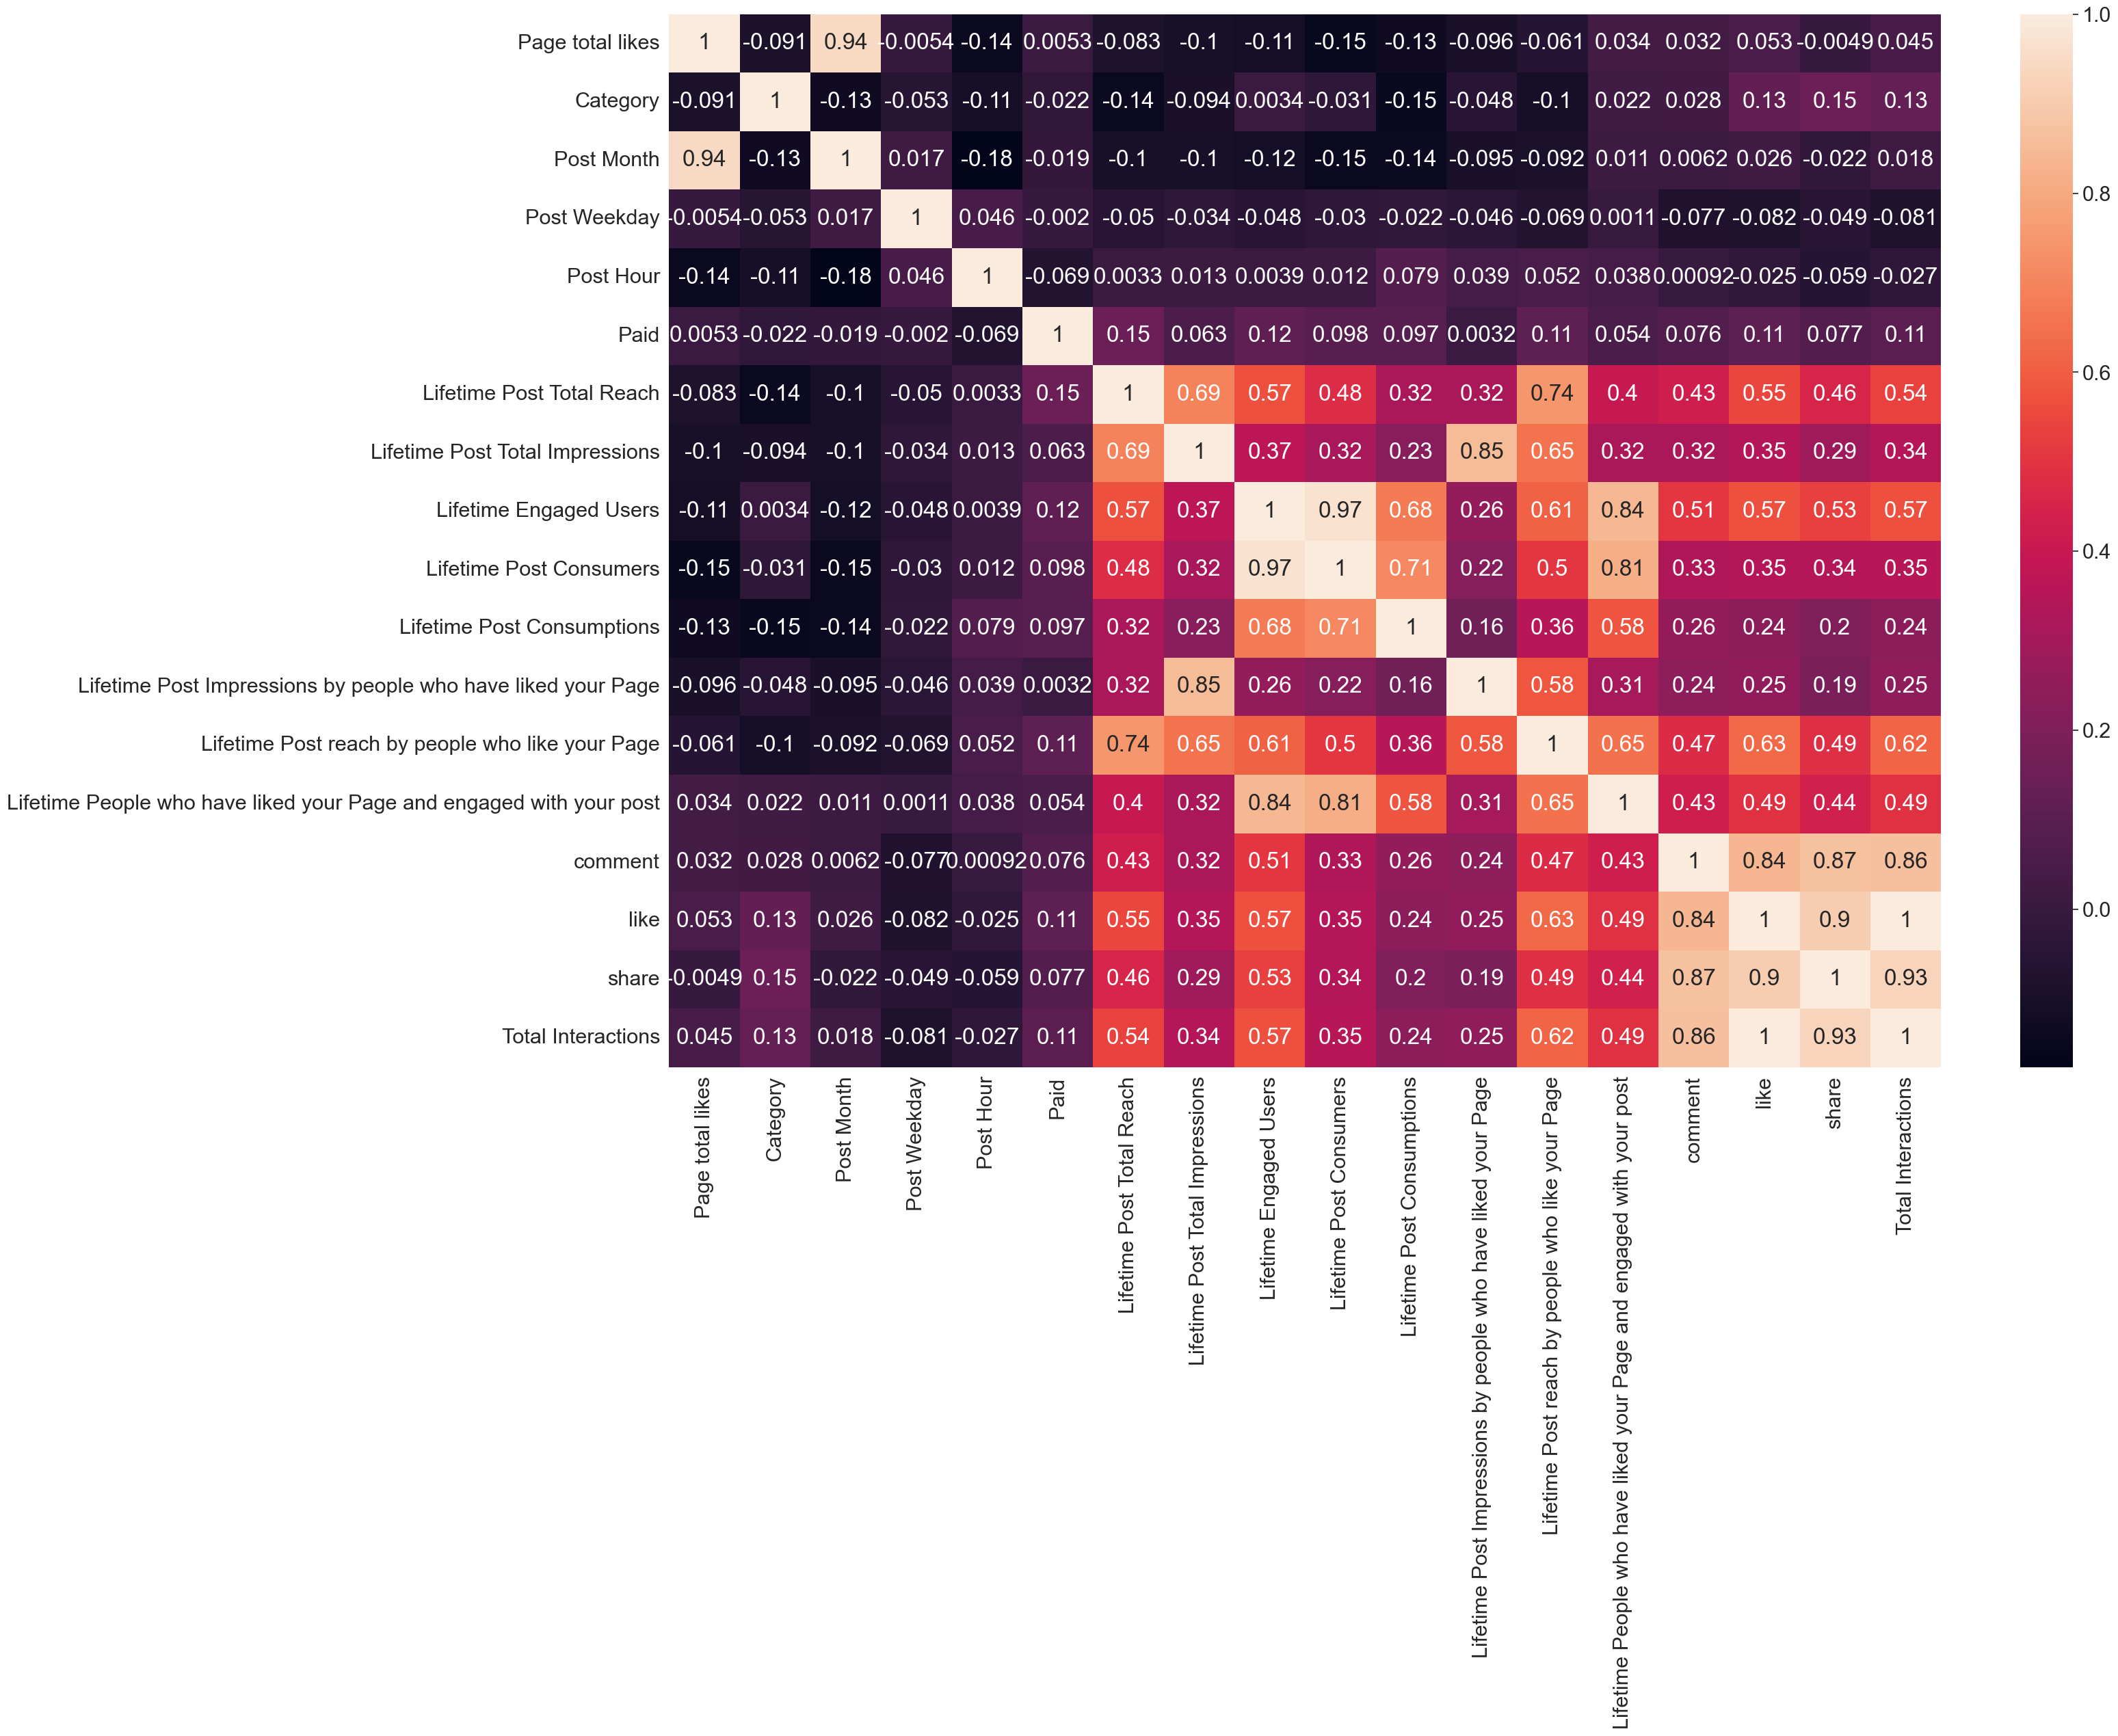

In [109]:
#Creating a heatmap to visualize correlations between variables with coefficients 
plt.figure(figsize = (30,20))
sns.set(font_scale = 2)
sns.heatmap(df.corr(numeric_only=True), annot = True); 

In the Facebook Metrics dataset, many variables are highly correlated with one another. However, despite these strong relationships, several metrics capture different dimensions of post performance and user engagement. As a result, even variables that appear statistically similar may still provide meaningful and distinct insights.

In [118]:
drop_columns = df_encoded.corr(numeric_only=True, method = "pearson")
print(drop_columns)

                                                    Page total likes  \
Page total likes                                            1.000000   
Category                                                   -0.091142   
Post Month                                                  0.941192   
Post Weekday                                               -0.005401   
Post Hour                                                  -0.143807   
Paid                                                        0.005341   
Lifetime Post Total Reach                                  -0.083245   
Lifetime Post Total Impressions                            -0.102540   
Lifetime Engaged Users                                     -0.111922   
Lifetime Post Consumers                                    -0.149129   
Lifetime Post Consumptions                                 -0.128240   
Lifetime Post Impressions by people who have li...         -0.096109   
Lifetime Post reach by people who like your Page           -0.06

In [116]:
#X is all of the data that is not our target
#Y is our target: Total Interact

X = df_encoded.drop('Lifetime Engaged Users', axis = 1)
Y = df_encoded['Lifetime Engaged Users']

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

We choose these specific columns as X's to scale becase the correlation was under the threshold of 0.8.

In [119]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
scaler.fit(X_train) 
X_train_scaled = scaler.transform(X_train)

In [120]:
X_to_scale = ["Lifetime Post Total Reach", "Lifetime Post Total Impressions", "Lifetime Post Consumptions", "Lifetime Post Impressions by people who have liked the Page", "Lifetime Post Reach by people who have liked the Page"]

In [124]:
# uploading new datframe into csv for future use
df_encoded.to_csv("/Users/sa19/class-projects/TKH-26-labs/Facebook-Metrics-Phase-1-Project/df_encoded.csv", index = False)